In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 13

In [2]:
hours = np.array([
    1,2,3,4,5,
    6,7,8,9,10
])

marks = np.array([
    18,26,35,43,51,
    60,68,74,83,92
])

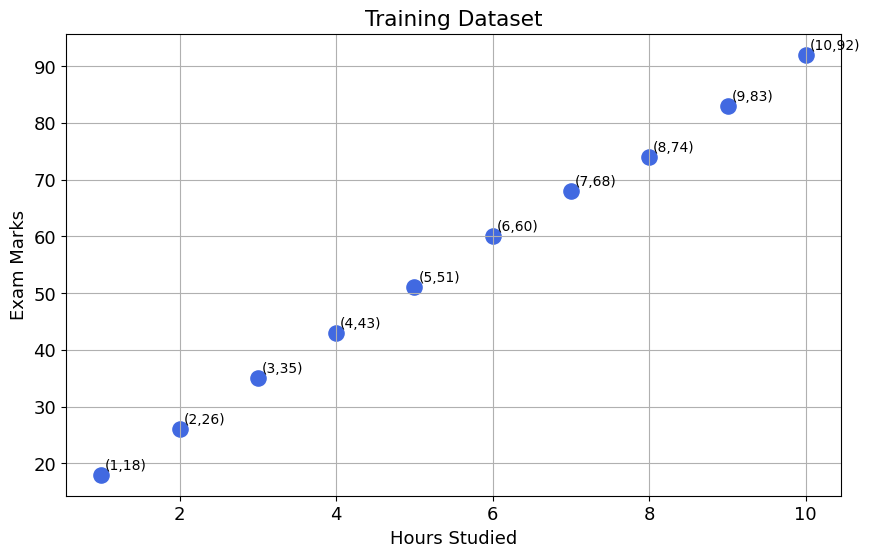

In [3]:
plt.figure(figsize=(10,6))

plt.scatter(
    hours,
    marks,
    s=120,
    color="royalblue"
)

for x,y in zip(hours,marks):
    plt.text(
        x+0.05,
        y+1,
        f"({x},{y})",
        fontsize=10
    )

plt.title("Training Dataset")

plt.xlabel("Hours Studied")

plt.ylabel("Exam Marks")

plt.grid(True)

plt.show()

In [4]:
# Initial guess
w = 7
b = 10

In [5]:
def predict(x, w, b):
    return w * x + b

In [6]:
predictions = predict(hours, w, b)

print(predictions)

[17 24 31 38 45 52 59 66 73 80]


In [7]:
for x, actual, pred in zip(hours, marks, predictions):
    print(f"Hours = {x:2d} | Actual = {actual:2d} | Predicted = {pred:2d}")

Hours =  1 | Actual = 18 | Predicted = 17
Hours =  2 | Actual = 26 | Predicted = 24
Hours =  3 | Actual = 35 | Predicted = 31
Hours =  4 | Actual = 43 | Predicted = 38
Hours =  5 | Actual = 51 | Predicted = 45
Hours =  6 | Actual = 60 | Predicted = 52
Hours =  7 | Actual = 68 | Predicted = 59
Hours =  8 | Actual = 74 | Predicted = 66
Hours =  9 | Actual = 83 | Predicted = 73
Hours = 10 | Actual = 92 | Predicted = 80


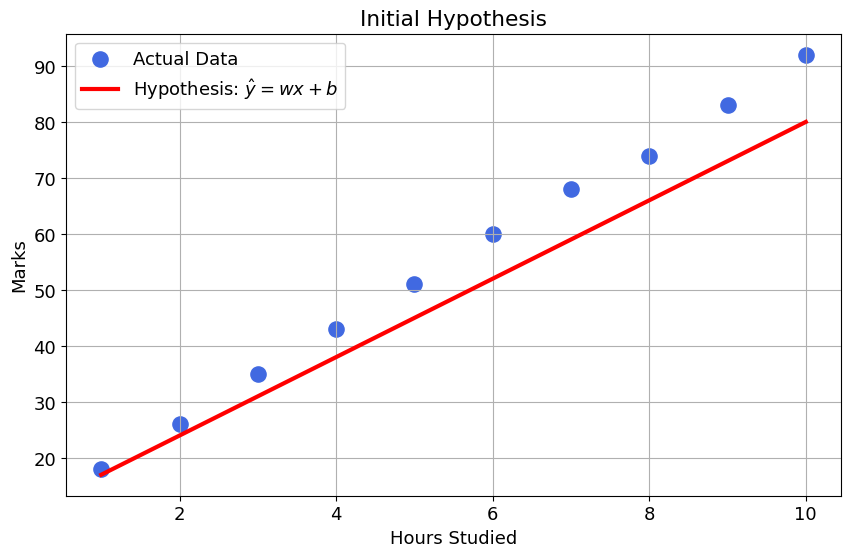

In [8]:
plt.figure(figsize=(10,6))

# Training data
plt.scatter(hours, marks,
            color="royalblue",
            s=120,
            label="Actual Data")

# Hypothesis line
plt.plot(hours,
         predictions,
         color="red",
         linewidth=3,
         label=r"Hypothesis: $\hat y = wx+b$")

plt.title("Initial Hypothesis")

plt.xlabel("Hours Studied")
plt.ylabel("Marks")

plt.grid(True)
plt.legend()

plt.show()

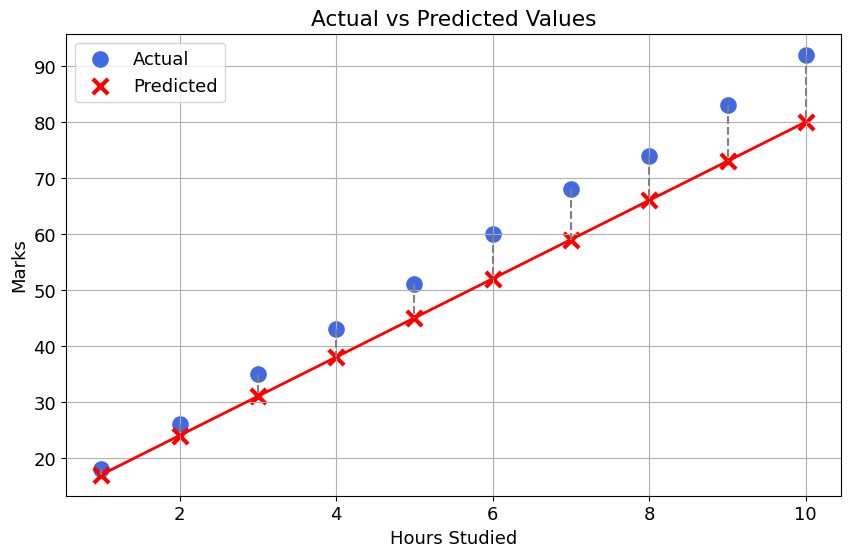

In [9]:
plt.figure(figsize=(10,6))

# Actual points
plt.scatter(hours, marks,
            s=120,
            color="royalblue",
            label="Actual")

# Predicted points
plt.scatter(hours,
            predictions,
            s=120,
            color="red",
            marker="x",
            linewidths=3,
            label="Predicted")

# Hypothesis line
plt.plot(hours,
         predictions,
         color="red",
         linewidth=2)

# Connect actual and predicted
for x, actual, pred in zip(hours, marks, predictions):
    plt.plot([x, x],
             [actual, pred],
             '--',
             color='gray')

plt.title("Actual vs Predicted Values")

plt.xlabel("Hours Studied")
plt.ylabel("Marks")

plt.grid(True)
plt.legend()

plt.show()

In [10]:
# Prediction Error (Residual)

errors = predictions - marks

print(errors)

[ -1  -2  -4  -5  -6  -8  -9  -8 -10 -12]


In [11]:
print("Hours | Actual | Predicted | Error")
print("-"*40)

for x, actual, pred, err in zip(hours, marks, predictions, errors):
    print(f"{x:^5} | {actual:^6} | {pred:^9} | {err:^5}")

Hours | Actual | Predicted | Error
----------------------------------------
  1   |   18   |    17     |  -1  
  2   |   26   |    24     |  -2  
  3   |   35   |    31     |  -4  
  4   |   43   |    38     |  -5  
  5   |   51   |    45     |  -6  
  6   |   60   |    52     |  -8  
  7   |   68   |    59     |  -9  
  8   |   74   |    66     |  -8  
  9   |   83   |    73     |  -10 
 10   |   92   |    80     |  -12 


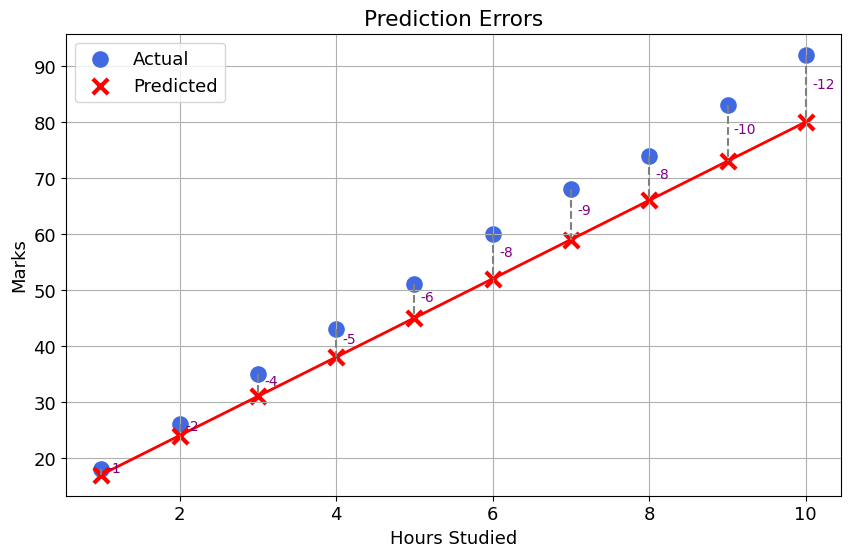

In [12]:
plt.figure(figsize=(10,6))

# Actual data
plt.scatter(hours, marks,
            s=120,
            color="royalblue",
            label="Actual")

# Predictions
plt.scatter(hours,
            predictions,
            s=120,
            color="red",
            marker="x",
            linewidth=3,
            label="Predicted")

# Hypothesis line
plt.plot(hours,
         predictions,
         color="red",
         linewidth=2)

# Error Lines + Labels
for x, actual, pred, err in zip(hours, marks, predictions, errors):

    plt.plot(
        [x,x],
        [actual,pred],
        '--',
        color='gray'
    )

    mid = (actual+pred)/2

    plt.text(
        x+0.08,
        mid,
        f"{err}",
        fontsize=10,
        color="purple"
    )

plt.title("Prediction Errors")

plt.xlabel("Hours Studied")
plt.ylabel("Marks")

plt.grid(True)
plt.legend()

plt.show()

In [13]:
squared_errors = errors**2

print(squared_errors)

[  1   4  16  25  36  64  81  64 100 144]


In [14]:
print("Error | Squared Error")
print("-"*25)

for e,se in zip(errors,squared_errors):

    print(f"{e:^7} | {se:^14}")

Error | Squared Error
-------------------------
  -1    |       1       
  -2    |       4       
  -4    |       16      
  -5    |       25      
  -6    |       36      
  -8    |       64      
  -9    |       81      
  -8    |       64      
  -10   |      100      
  -12   |      144      


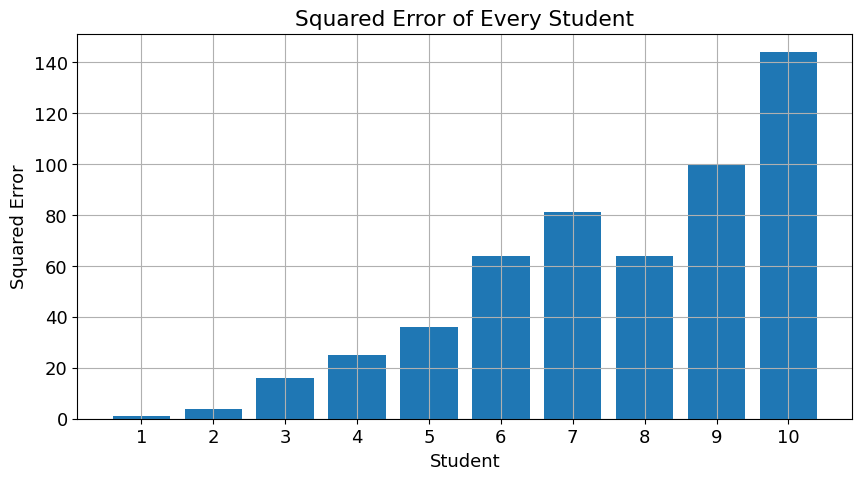

In [15]:
plt.figure(figsize=(10,5))

plt.bar(
    range(len(squared_errors)),
    squared_errors
)

plt.xticks(range(len(hours)),hours)

plt.xlabel("Student")

plt.ylabel("Squared Error")

plt.title("Squared Error of Every Student")

plt.grid(True)

plt.show()

In [16]:
m = len(hours)

cost = np.sum(squared_errors)/(2*m)

print("Cost =",cost)

Cost = 26.75


In [17]:
def compute_cost(x, y, w, b):

    predictions = w * x + b

    errors = predictions - y

    squared_errors = errors ** 2

    m = len(x)

    cost = np.sum(squared_errors) / (2 * m)

    return cost

In [18]:
weights = [2,4,6,8,10]

for w in weights:

    cost = compute_cost(hours, marks, w, b)

    print(f"w = {w:2d}   Cost = {cost:.2f}")

w =  2   Cost = 734.00
w =  4   Cost = 335.60
w =  6   Cost = 91.20
w =  8   Cost = 0.80
w = 10   Cost = 64.40


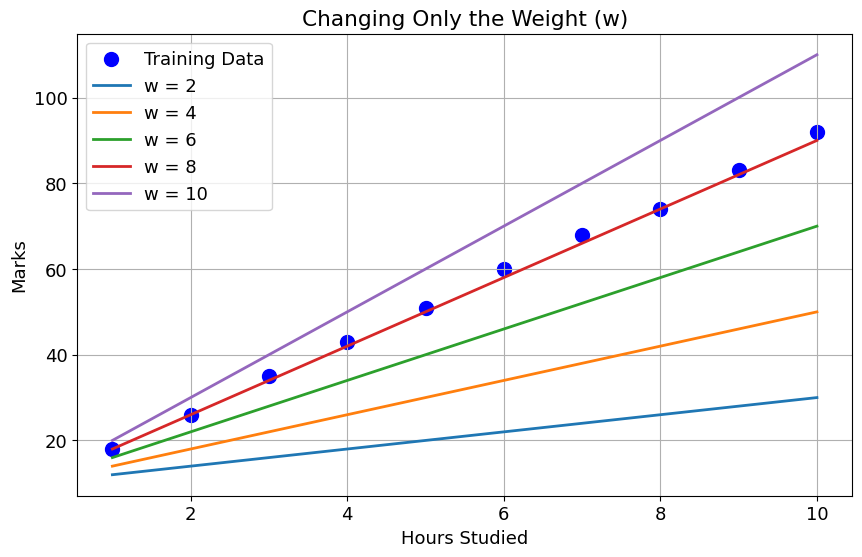

In [19]:
weights = [2,4,6,8,10]

plt.figure(figsize=(10,6))

plt.scatter(hours,
            marks,
            color="blue",
            s=100,
            label="Training Data")

for w in weights:

    predictions = w*hours + b

    plt.plot(hours,
             predictions,
             linewidth=2,
             label=f"w = {w}")

plt.xlabel("Hours Studied")
plt.ylabel("Marks")

plt.title("Changing Only the Weight (w)")

plt.grid(True)
plt.legend()

plt.show()

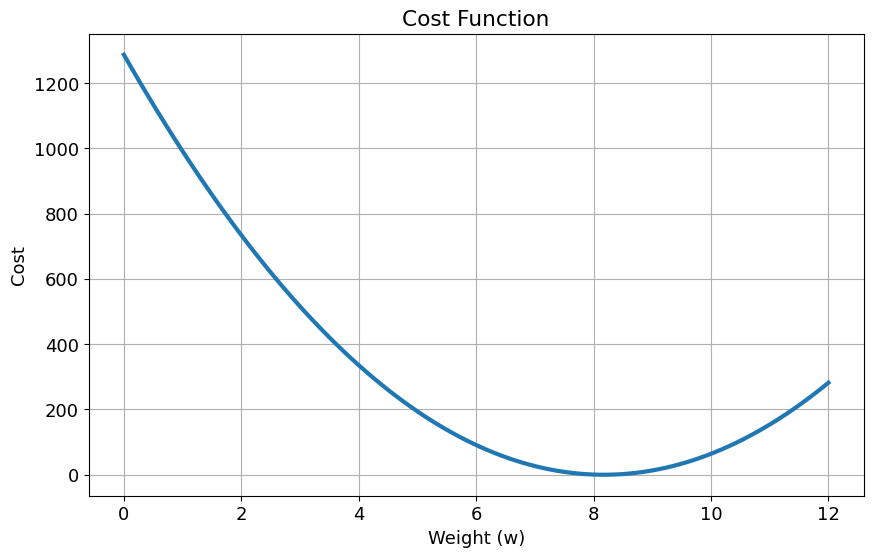

In [20]:
weights = np.linspace(0,12,100)

costs = []

for w in weights:

    costs.append(
        compute_cost(hours,
                     marks,
                     w,
                     b)
    )

plt.figure(figsize=(10,6))

plt.plot(weights,
         costs,
         linewidth=3)

plt.xlabel("Weight (w)")

plt.ylabel("Cost")

plt.title("Cost Function")

plt.grid(True)

plt.show()

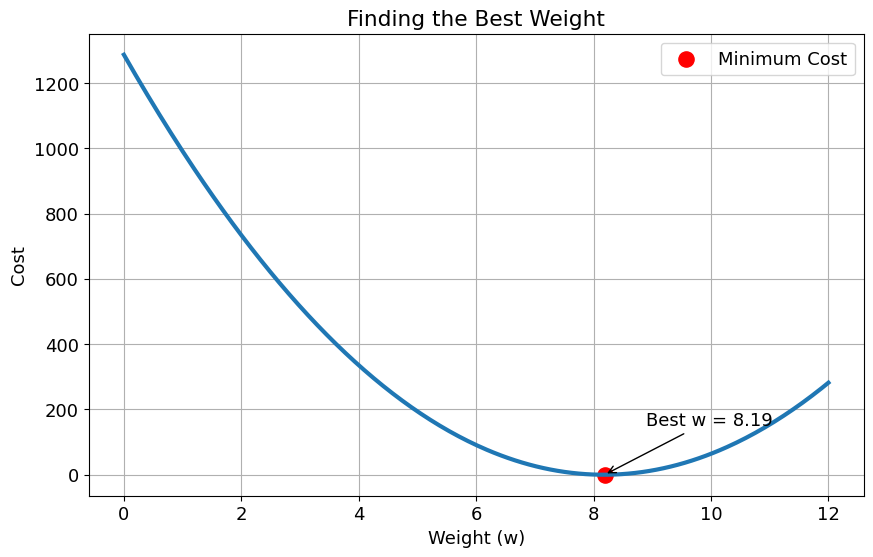

Best weight ≈ 8.187
Minimum cost ≈ 0.220


In [21]:
weights = np.linspace(0,12,300)

costs = []

for w in weights:
    costs.append(compute_cost(hours, marks, w, b))

costs = np.array(costs)

best_index = np.argmin(costs)

best_w = weights[best_index]
best_cost = costs[best_index]

plt.figure(figsize=(10,6))

plt.plot(weights,
         costs,
         linewidth=3)

plt.scatter(best_w,
            best_cost,
            color="red",
            s=120,
            label="Minimum Cost")

plt.annotate(
    f"Best w = {best_w:.2f}",
    xy=(best_w, best_cost),
    xytext=(best_w+0.7, best_cost+150),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Weight (w)")
plt.ylabel("Cost")

plt.title("Finding the Best Weight")

plt.grid(True)
plt.legend()

plt.show()

print(f"Best weight ≈ {best_w:.3f}")
print(f"Minimum cost ≈ {best_cost:.3f}")

In [22]:
from mpl_toolkits.mplot3d import Axes3D

In [23]:
w_values = np.linspace(0, 12, 80)
b_values = np.linspace(-20, 30, 80)

W, B = np.meshgrid(w_values, b_values)

In [24]:
J = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):

        J[i, j] = compute_cost(
            hours,
            marks,
            W[i, j],
            B[i, j]
        )

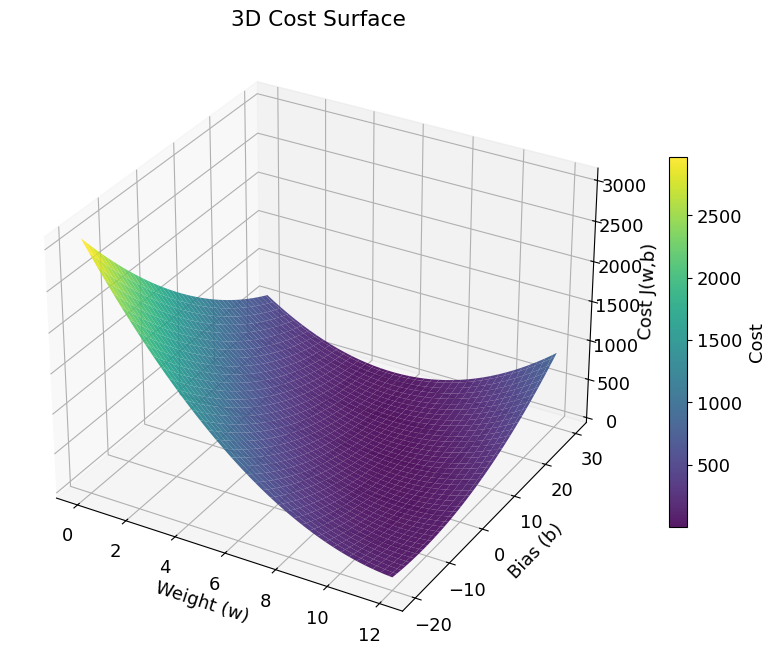

In [25]:
fig = plt.figure(figsize=(11,8))

ax = fig.add_subplot(111, projection="3d")

surface = ax.plot_surface(
    W,
    B,
    J,
    cmap="viridis",
    edgecolor="none",
    alpha=0.9
)

ax.set_xlabel("Weight (w)")
ax.set_ylabel("Bias (b)")
ax.set_zlabel("Cost J(w,b)")

ax.set_title("3D Cost Surface")

fig.colorbar(surface, shrink=0.6, label="Cost")

plt.show()

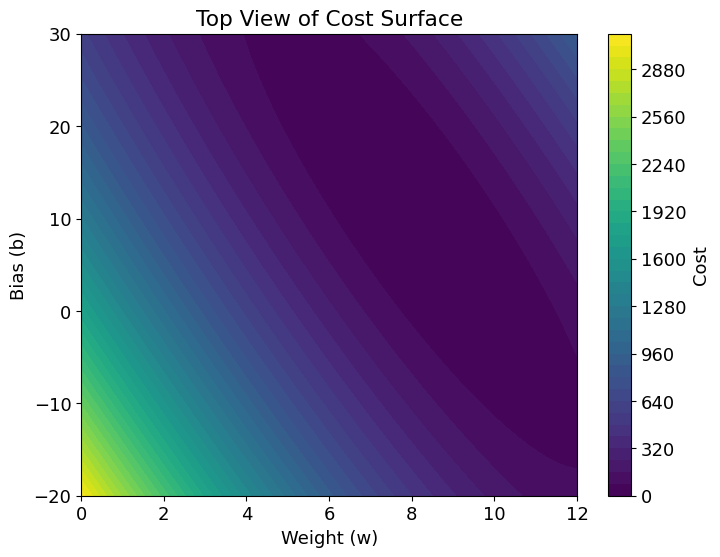

In [26]:
plt.figure(figsize=(8,6))

contour = plt.contourf(
    W,
    B,
    J,
    levels=40,
    cmap="viridis"
)

plt.colorbar(label="Cost")

plt.xlabel("Weight (w)")
plt.ylabel("Bias (b)")

plt.title("Top View of Cost Surface")

plt.show()

In [27]:
best_index = np.unravel_index(np.argmin(J), J.shape)

best_w = W[best_index]
best_b = B[best_index]
best_cost = J[best_index]

print(f"Best Weight = {best_w:.3f}")
print(f"Best Bias   = {best_b:.3f}")
print(f"Minimum Cost = {best_cost:.3f}")

Best Weight = 8.203
Best Bias   = 9.747
Minimum Cost = 0.236


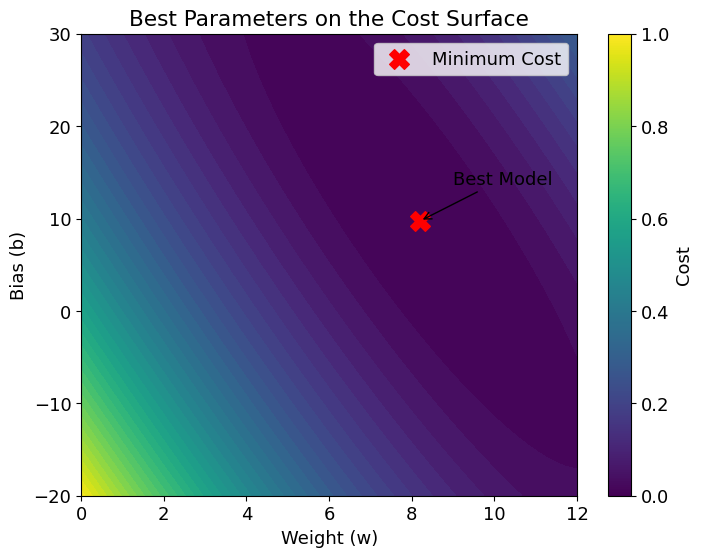

In [28]:
plt.figure(figsize=(8,6))

plt.contourf(
    W,
    B,
    J,
    levels=40,
    cmap="viridis"
)

plt.scatter(
    best_w,
    best_b,
    color="red",
    s=200,
    marker="X",
    label="Minimum Cost"
)

plt.annotate(
    "Best Model",
    xy=(best_w, best_b),
    xytext=(best_w + 0.8, best_b + 4),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Weight (w)")
plt.ylabel("Bias (b)")
plt.title("Best Parameters on the Cost Surface")

plt.legend()

plt.colorbar(label="Cost")

plt.show()

In [29]:
w = 1.0
b = -5.0

learning_rate = 0.01

iterations = 100

In [30]:
def compute_gradients(x, y, w, b):

    m = len(x)

    predictions = w*x + b

    errors = predictions - y

    dj_dw = np.sum(errors * x) / m

    dj_db = np.sum(errors) / m

    return dj_dw, dj_db

In [31]:
dj_dw, dj_db = compute_gradients(
    hours,
    marks,
    w,
    b
)

print("Gradient w =", dj_dw)
print("Gradient b =", dj_db)

Gradient w = -358.7
Gradient b = -54.5


In [32]:
w = w - learning_rate * dj_dw

b = b - learning_rate * dj_db

print("New w =", w)
print("New b =", b)

New w = 4.587
New b = -4.455


In [33]:
cost = compute_cost(
    hours,
    marks,
    w,
    b
)

print(cost)

638.17259825


In [34]:
w = 1.0
b = -5.0

learning_rate = 0.01

iterations = 100

cost_history = []

w_history = []

b_history = []

for i in range(iterations):

    dj_dw, dj_db = compute_gradients(
        hours,
        marks,
        w,
        b
    )

    w = w - learning_rate * dj_dw

    b = b - learning_rate * dj_db

    cost = compute_cost(
        hours,
        marks,
        w,
        b
    )

    cost_history.append(cost)

    w_history.append(w)

    b_history.append(b)

print("Training Complete")

Training Complete


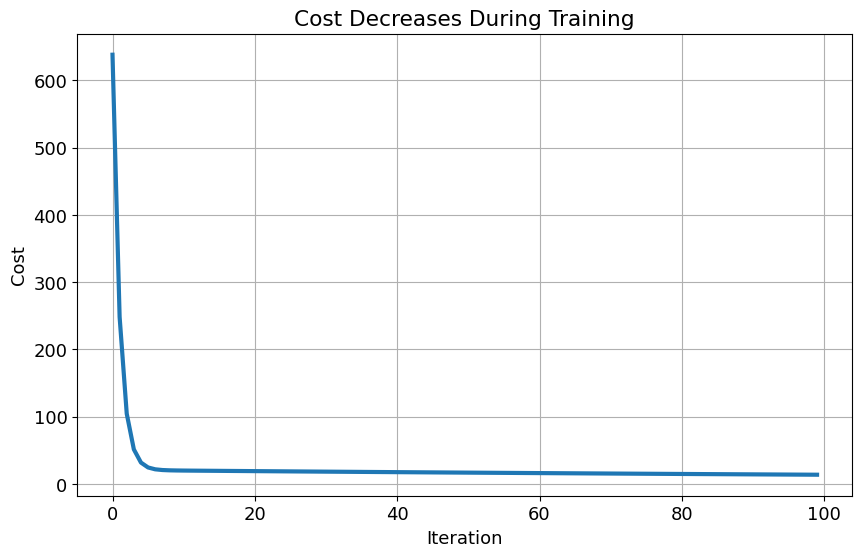

In [35]:
plt.figure(figsize=(10,6))

plt.plot(
    cost_history,
    linewidth=3
)

plt.xlabel("Iteration")

plt.ylabel("Cost")

plt.title("Cost Decreases During Training")

plt.grid(True)

plt.show()

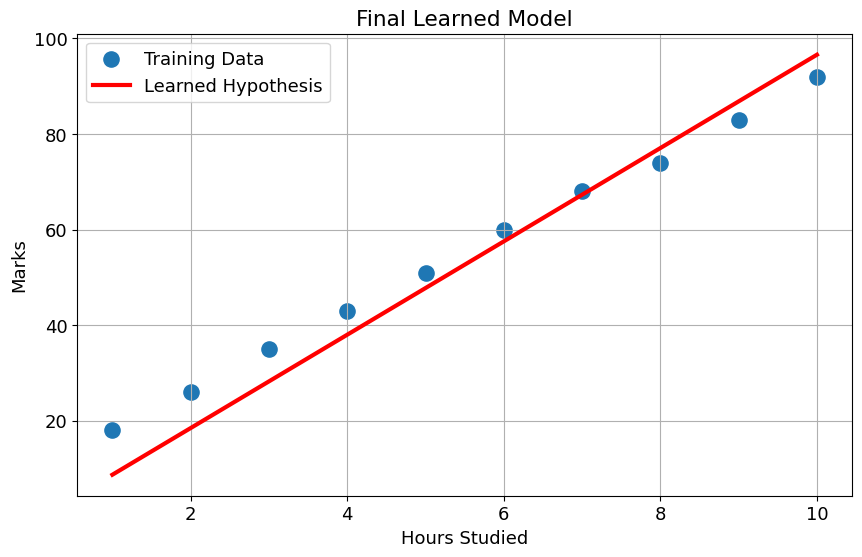

Final Weight = 9.762047880605119
Final Bias = -1.0544356422772878


In [36]:
predictions = w * hours + b

plt.figure(figsize=(10,6))

plt.scatter(
    hours,
    marks,
    s=120,
    label="Training Data"
)

plt.plot(
    hours,
    predictions,
    color="red",
    linewidth=3,
    label="Learned Hypothesis"
)

plt.xlabel("Hours Studied")

plt.ylabel("Marks")

plt.title("Final Learned Model")

plt.grid(True)

plt.legend()

plt.show()

print("Final Weight =", w)
print("Final Bias =", b)

In [37]:
new_hours = 7.5

predicted_marks = w * new_hours + b

print(f"Hours Studied : {new_hours}")
print(f"Predicted Marks : {predicted_marks:.2f}")

Hours Studied : 7.5
Predicted Marks : 72.16


### Visualization of Cost Functions

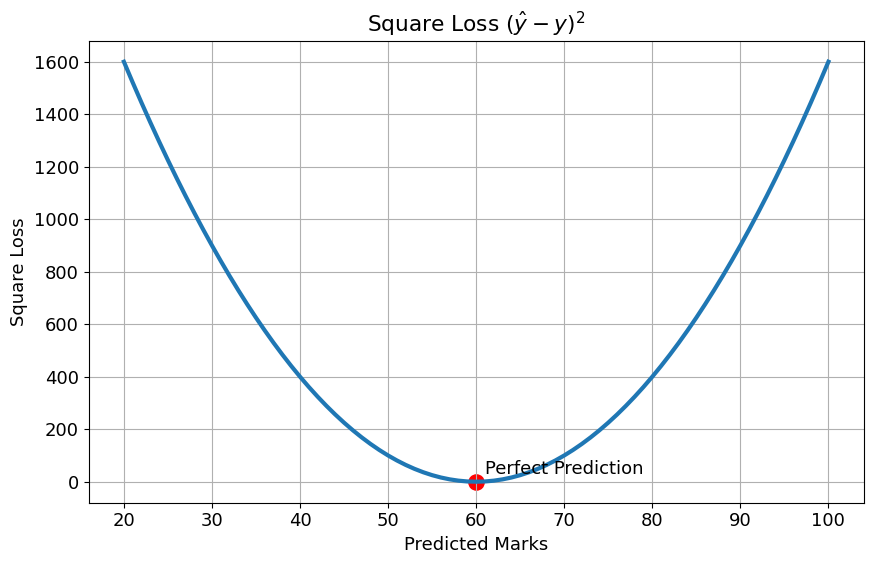

In [38]:
import numpy as np
import matplotlib.pyplot as plt

actual = 60

predicted = np.arange(20,101)

square_loss = (predicted-actual)**2

plt.figure(figsize=(10,6))

plt.plot(predicted,
         square_loss,
         linewidth=3)

plt.scatter(actual,0,
            color="red",
            s=120)

plt.text(actual+1,
         30,
         "Perfect Prediction")

plt.xlabel("Predicted Marks")

plt.ylabel("Square Loss")

plt.title(r"Square Loss $(\hat y-y)^2$")

plt.grid(True)

plt.show()

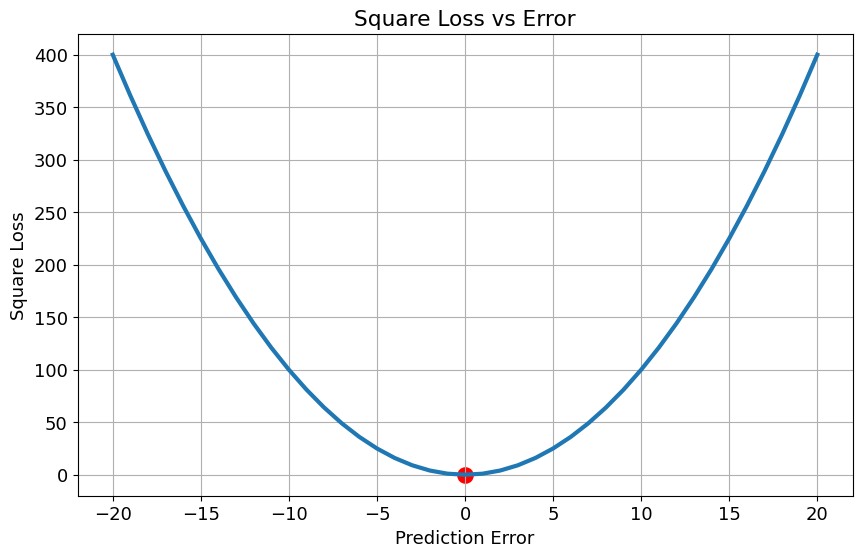

In [39]:
errors = np.arange(-20,21)

square_loss = errors**2

plt.figure(figsize=(10,6))

plt.plot(errors,
         square_loss,
         linewidth=3)

plt.scatter(0,0,
            color="red",
            s=120)

plt.xlabel("Prediction Error")

plt.ylabel("Square Loss")

plt.title(r"Square Loss vs Error")

plt.grid(True)

plt.show()

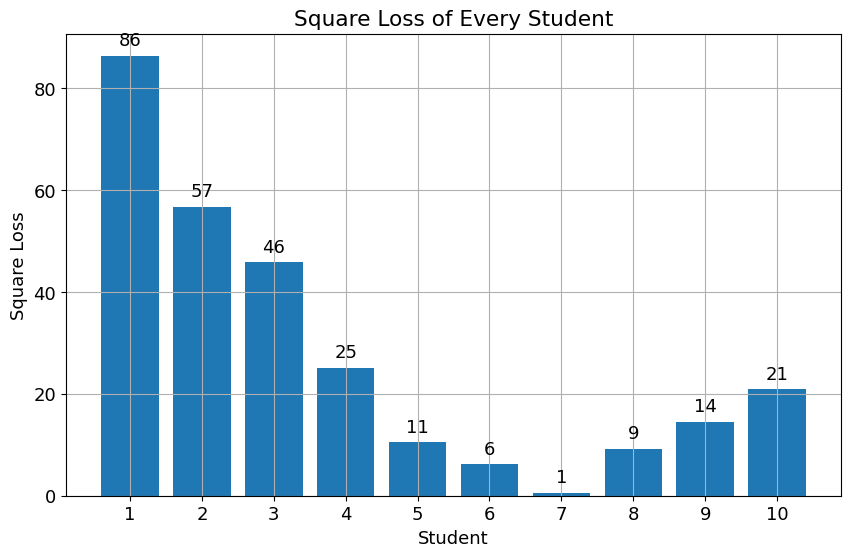

In [40]:
predictions = w*hours+b

errors = predictions-marks

square_loss = errors**2

plt.figure(figsize=(10,6))

bars = plt.bar(
    range(len(hours)),
    square_loss
)

plt.xticks(range(len(hours)),hours)

for i,v in enumerate(square_loss):

    plt.text(i,
             v+2,
             f"{v:.0f}",
             ha='center')

plt.xlabel("Student")

plt.ylabel("Square Loss")

plt.title("Square Loss of Every Student")

plt.grid(True)

plt.show()

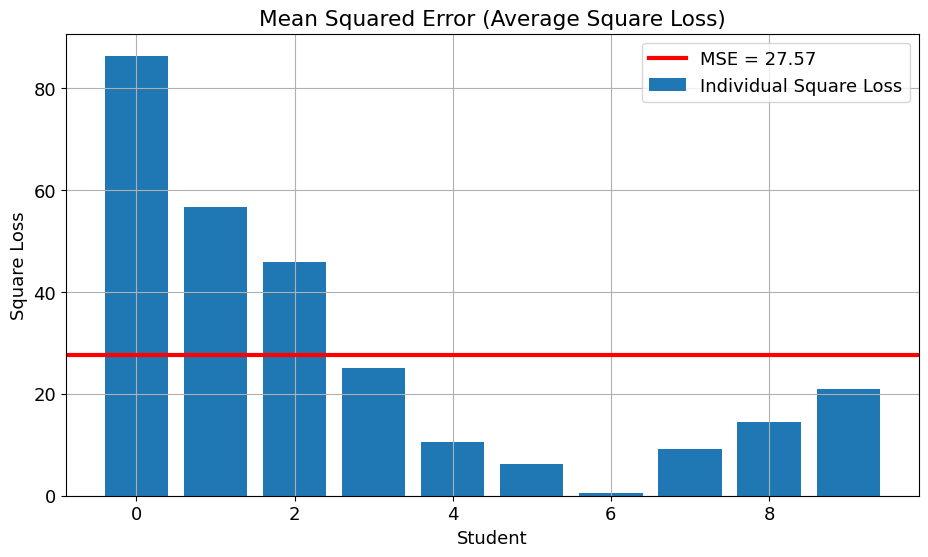

In [41]:
mse = np.mean(square_loss)

plt.figure(figsize=(11,6))

plt.bar(
    range(len(hours)),
    square_loss,
    label="Individual Square Loss"
)

plt.axhline(
    mse,
    color="red",
    linewidth=3,
    label=f"MSE = {mse:.2f}"
)

plt.xlabel("Student")

plt.ylabel("Square Loss")

plt.title("Mean Squared Error (Average Square Loss)")

plt.legend()

plt.grid(True)

plt.show()

In [42]:
print("Square Losses\n")

for loss in square_loss:

    print(loss)

print("\n")

print("Average (MSE) =",np.mean(square_loss))

Square Losses

86.3484703132747
56.70601872438891
45.80977660351695
25.06248018760095
10.524809238774873
6.161060474331891
0.5185446984755382
9.253443999963826
14.470380114370391
20.848750173446348


Average (MSE) = 27.570373452814444


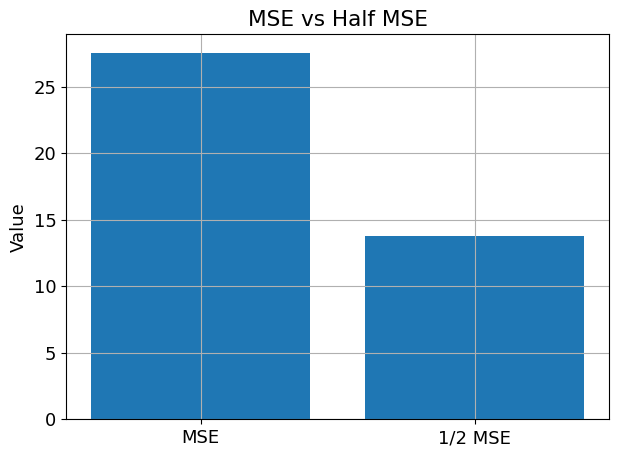

MSE = 27.570373452814444
Half MSE = 13.785186726407222


In [43]:
mse = np.mean(square_loss)

half_mse = mse/2

plt.figure(figsize=(7,5))

plt.bar(
    ["MSE","1/2 MSE"],
    [mse,half_mse]
)

plt.ylabel("Value")

plt.title("MSE vs Half MSE")

plt.grid(True)

plt.show()

print("MSE =",mse)

print("Half MSE =",half_mse)

In [44]:
print("For Each Student\n")

for i in range(len(hours)):

    print(f"""
Student {i+1}

Actual        = {marks[i]}

Prediction    = {predictions[i]:.2f}

Error         = {errors[i]:.2f}

Square Loss   = {square_loss[i]:.2f}
""")

print("--------------------------------")

print(f"Mean Square Loss = {np.mean(square_loss):.2f}")

print(f"Half Mean Square Loss = {np.mean(square_loss)/2:.2f}")

For Each Student


Student 1

Actual        = 18

Prediction    = 8.71

Error         = -9.29

Square Loss   = 86.35


Student 2

Actual        = 26

Prediction    = 18.47

Error         = -7.53

Square Loss   = 56.71


Student 3

Actual        = 35

Prediction    = 28.23

Error         = -6.77

Square Loss   = 45.81


Student 4

Actual        = 43

Prediction    = 37.99

Error         = -5.01

Square Loss   = 25.06


Student 5

Actual        = 51

Prediction    = 47.76

Error         = -3.24

Square Loss   = 10.52


Student 6

Actual        = 60

Prediction    = 57.52

Error         = -2.48

Square Loss   = 6.16


Student 7

Actual        = 68

Prediction    = 67.28

Error         = -0.72

Square Loss   = 0.52


Student 8

Actual        = 74

Prediction    = 77.04

Error         = 3.04

Square Loss   = 9.25


Student 9

Actual        = 83

Prediction    = 86.80

Error         = 3.80

Square Loss   = 14.47


Student 10

Actual        = 92

Prediction    = 96.57

Error         = 4.57

S